In [1]:
import os
import numpy as np
import rasterio
import xarray as xr

In [ ]:
xdata = xr.open_dataset('unprocessed_data/WEATHER/ST2020IA0004_Soybean.nc')
xdata['data'].isel(band=0, time=0).plot()

In [ ]:
with rasterio.open('/work/mech-ai-scratch/bgekim/project/ISA_Yield_Anirudha/ISA_Yield/chloe_dataset/yield_geotiffs/ST2021IANC030_Corn.tif') as dataset:
    # Get the shape (height, width) and number of bands
    height, width = dataset.shape
    bands = dataset.count
    print(dataset.shape)
    

(21, 80)


In [ ]:
np.load('unprocessed_data/S1GRD/ST2024IA0008_Soybean.tif',allow_pickle=True)

In [ ]:
test = np.load('unprocessed_data/WEATHER/ST2019IA0007_Soybean.npy')
test.shape

In [7]:
test = np.load('processed_data_biweekly_3/WEATHER/ST2019IA0010_Soybean.npy')
test.shape

(1, 7, 224, 224)

In [ ]:
root_dir = './data_download/S1/final_s1'
cnt = 0
"""
Walk through subfolders, read GeoTIFF files, and print their shapes.

Args:
    root_dir (str): Path to the root directory containing GeoTIFF files.
"""
# Walk through all subfolders and files in the root directory
for root, dirs, files in os.walk(root_dir):
    for file in files:
        # Check if the file is a GeoTIFF (.tif or .tiff, case-insensitive)
        if file.lower().endswith(('.tif', '.tiff')):
            file_path = os.path.join(root, file)
            try:
                # Open the GeoTIFF file using rasterio
                with rasterio.open(file_path) as dataset:
                    # Get the shape (height, width) and number of bands
                    height, width = dataset.shape
                    bands = dataset.count
                    print(f"File: {file_path}")
                    print(f"Shape: (height={height}, width={width}, bands={bands})")
                    print("-" * 50)
            except rasterio.errors.RasterioIOError as e:
                print(f"Error reading {file_path}: {e}")
            except Exception as e:
                print(f"Unexpected error with {file_path}: {e}")

In [ ]:
root_dir = './processed_data_biweekly_12/yield_geotiffs'
cnt = 0
"""
Walk through subfolders, read GeoTIFF files, and print their shapes.

Args:
    root_dir (str): Path to the root directory containing GeoTIFF files.
"""
# Walk through all subfolders and files in the root directory
for root, dirs, files in os.walk(root_dir):
    for file in files:
        # Check if the file is a GeoTIFF (.tif or .tiff, case-insensitive)
        if file.lower().endswith(('.tif', '.tiff')):
            file_path = os.path.join(root, file)
            try:
                # Open the GeoTIFF file using rasterio
                with rasterio.open(file_path) as dataset:
                    # Get the shape (height, width) and number of bands
                    height, width = dataset.shape
                    bands = dataset.count
                    print(f"File: {file_path}")
                    print(f"Shape: (height={height}, width={width}, bands={bands})")
                    print("-" * 50)
            except rasterio.errors.RasterioIOError as e:
                print(f"Error reading {file_path}: {e}")
            except Exception as e:
                print(f"Unexpected error with {file_path}: {e}")

In [ ]:
import geopandas as gpd
import alphashape
from shapely.geometry import MultiPoint

# Read points
gdf = gpd.read_parquet('Yield_2020_filtered.parquet')

# Only set a CRS if it's missing
if gdf.crs is None:
    gdf = gdf.set_crs("EPSG:4326", allow_override=True)

# Drop rows with missing geometry
gdf = gdf.dropna(subset=["geometry"]).copy()

# Compute alphashape per Layer_ID for tighter boundaries
# alpha=0 gives convex hull, larger values give tighter fit
# Start with alpha=2.0, adjust as needed
def compute_alphashape(points_series, alpha=5.0):
    """Compute alphashape from a series of point geometries."""
    try:
        # Extract coordinates from point geometries
        coords = [(pt.x, pt.y) for pt in points_series]
        if len(coords) < 4:
            # For very few points, fall back to convex hull
            return MultiPoint(coords).convex_hull
        # Compute alphashape
        return alphashape.alphashape(coords, alpha)
    except Exception as e:
        # Fallback to convex hull on error
        return points_series.unary_union.convex_hull

# Apply alphashape per Layer_ID
geom = gdf.groupby("Layer_ID")["geometry"].agg(compute_alphashape)

hull_df = geom.reset_index(name="geometry")
hull_gdf = gpd.GeoDataFrame(hull_df, geometry="geometry")

# Set CRS to match source
hull_gdf = hull_gdf.set_crs(gdf.crs, allow_override=True)

hull_gdf.head()

In [ ]:
gdf.crs

In [ ]:
import matplotlib.pyplot as plt
# Select a specific Polygon (e.g., the first one)
selected_polygon = hull_gdf[hull_gdf['Layer_ID']=='ST2020IA0076'].geometry

# Create a Matplotlib figure and axes
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

# Plot the selected Polygon on the axes
selected_polygon.plot(ax=ax, color='blue', edgecolor='black')

# Set plot title and labels (optional)
ax.set_title("Visualization of a Single Polygon")
ax.set_xlabel("X-coordinate")
ax.set_ylabel("Y-coordinate")

# Display the plot
plt.show()

Subfolders: ['DEM', 'S2L2A', 'yield_geotiffs', 'SOIL', 'WEATHER', 'S1GRD']
DEM: processed_data_weekly_11/DEM/ST2019IA0033_Corn.npy, shape=(11, 1, 224, 224), dtype=float32


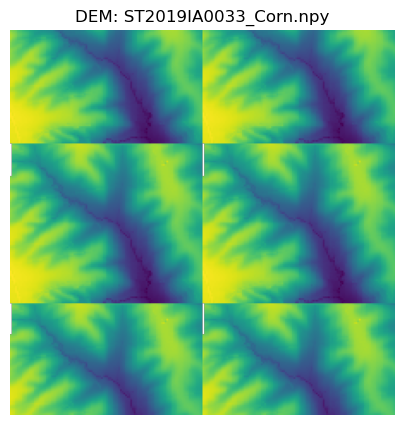

S2L2A: processed_data_weekly_11/S2L2A/ST2019IA0033_Corn.npy, shape=(11, 12, 224, 224), dtype=float32


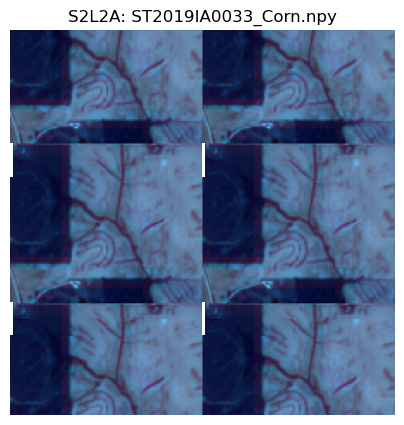

yield_geotiffs: processed_data_weekly_11/yield_geotiffs/ST2019IA0033_Corn.npy, shape=(1, 224, 224), dtype=float32


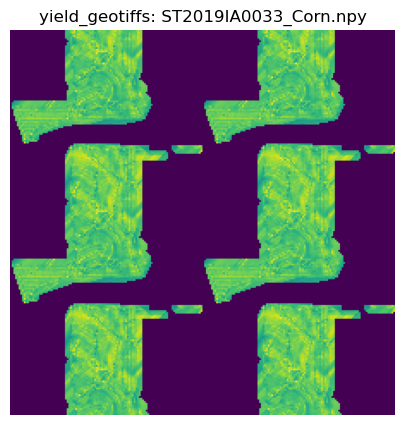

SOIL: processed_data_weekly_11/SOIL/ST2019IA0033_Corn.npy, shape=(11, 10, 224, 224), dtype=float32


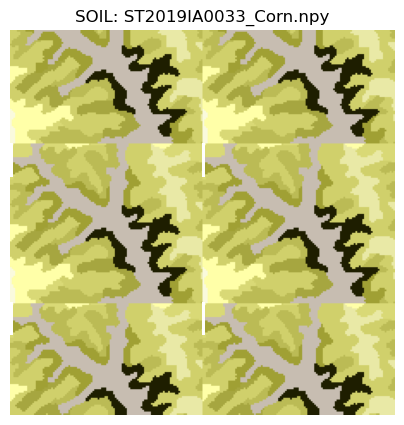

WEATHER: processed_data_weekly_11/WEATHER/ST2019IA0033_Corn.npy, shape=(11, 7, 224, 224), dtype=float32


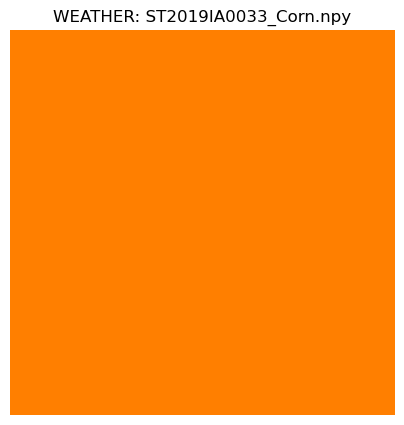

S1GRD: processed_data_weekly_11/S1GRD/ST2019IA0033_Corn.npy, shape=(11, 2, 224, 224), dtype=float32


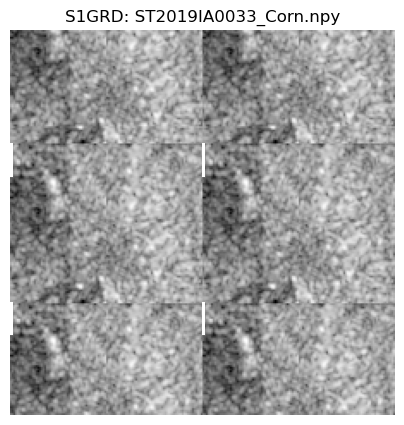

In [3]:
# Visualize a file from each subfolder in processed_data_biweekly_12 -- visualize Chloe **
import os
import numpy as np
import matplotlib.pyplot as plt

root_dir = "processed_data_weekly_11"
subfolders = [f for f in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, f))]
print("Subfolders:", subfolders)
sub_path = os.path.join(root_dir, subfolders[0])
# file_name = 'ST2023IA0189_Corn.npy'  # Example file name present in all subfolders
file_name = [f for f in os.listdir(sub_path) if f.lower().endswith('.npy')][100]
for sub in subfolders:
    file_path = os.path.join(root_dir, sub, file_name)
    arr = np.load(file_path)
    print(f"{sub}: {file_path}, shape={arr.shape}, dtype={arr.dtype}")
    # Handle shape: (T, C, H, W) or (C, H, W)
    if arr.ndim == 4:
        # Visualize first time step
        img = arr[7]
    elif arr.ndim == 3:
        img = arr
    else:
        print(f"Skipping {file_path}: unexpected shape {arr.shape}")
        continue

    # Use first 3 channels if more
    if img.shape[0] > 3:
        img = img[:3]
    elif img.shape[0] == 2:
        img = np.concatenate([img[:1], img[:1], img[:1]], axis=0)
    # Transpose to H, W, C for matplotlib
    img = np.moveaxis(img, 0, -1)
    # Normalize for visualization
    img_min, img_max = np.nanmin(img), np.nanmax(img)
    if img_max > img_min:
        img_vis = (img - img_min) / (img_max - img_min)
    else:
        img_vis = img

    plt.figure(figsize=(5, 5))
    plt.imshow(img_vis)
    plt.title(f"{sub}: {file_name}")
    plt.axis('off')
    plt.show()

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import re

folder_path = 'processed_data_biweekly_12/S1RTC'

# Dictionary to store counts: {year: {crop: [counts of all-zero time steps per file]}}
data_by_year_crop = {}

if os.path.isdir(folder_path):
    for file in os.listdir(folder_path):
        if file.lower().endswith('.npy'):
            # Extract year and crop from filename using regex
            match = re.match(r'ST(\d{4}).*_(Corn|Soybean)\.npy', file, re.IGNORECASE)
            if not match:
                print(f"Filename doesn't match expected pattern: {file}")
                continue
            
            year = match.group(1)
            crop = match.group(2).capitalize()
            
            file_path = os.path.join(folder_path, file)
            try:
                arr = np.load(file_path)
                # arr.shape is (N, C, H, W) where N=12
                N, C, H, W = arr.shape
                
                # Count how many time steps are fully zero
                all_zero_count = 0
                for n in range(N):
                    if np.all(arr[n, :, :, :] == 0):
                        all_zero_count += 1
                
                # Store the count
                if year not in data_by_year_crop:
                    data_by_year_crop[year] = {}
                if crop not in data_by_year_crop[year]:
                    data_by_year_crop[year][crop] = []
                
                data_by_year_crop[year][crop].append(all_zero_count)
                    
            except Exception as e:
                print(f"Error loading {file_path}: {e}")
    
    # Create visualizations
    years = sorted(data_by_year_crop.keys())
    crops = ['Corn', 'Soybean']
    
    # Plot 1: Distribution by year and crop
    fig, axes = plt.subplots(len(years), 2, figsize=(14, 4*len(years)))
    if len(years) == 1:
        axes = axes.reshape(1, -1)
    
    for i, year in enumerate(years):
        for j, crop in enumerate(crops):
            ax = axes[i, j]
            if crop in data_by_year_crop[year]:
                counts = data_by_year_crop[year][crop]
                ax.hist(counts, bins=range(0, 14), edgecolor='black', alpha=0.7, align='left')
                ax.set_xlabel('Number of All-Zero Time Steps (out of 12)')
                ax.set_ylabel('Frequency')
                ax.set_title(f'{year} - {crop} (n={len(counts)} files)')
                ax.set_xticks(range(0, 13))
                ax.grid(True, alpha=0.3)
                
                # Add statistics
                mean_zeros = np.mean(counts)
                median_zeros = np.median(counts)
                ax.axvline(mean_zeros, color='r', linestyle='--', label=f'Mean: {mean_zeros:.2f}')
                ax.axvline(median_zeros, color='g', linestyle='--', label=f'Median: {median_zeros:.2f}')
                ax.legend()
            else:
                ax.text(0.5, 0.5, f'No {crop} data for {year}', 
                       ha='center', va='center', transform=ax.transAxes)
                ax.set_xlabel('Number of All-Zero Time Steps (out of 12)')
                ax.set_ylabel('Frequency')
                ax.set_title(f'{year} - {crop}')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*60)
    print("SUMMARY STATISTICS")
    print("="*60)
    for year in years:
        print(f"\nYear: {year}")
        for crop in crops:
            if crop in data_by_year_crop[year]:
                counts = data_by_year_crop[year][crop]
                print(f"  {crop}:")
                print(f"    Total files: {len(counts)}")
                print(f"    Mean all-zero time steps: {np.mean(counts):.2f}")
                print(f"    Median all-zero time steps: {np.median(counts):.2f}")
                print(f"    Min: {np.min(counts)}, Max: {np.max(counts)}")
                print(f"    Files with 0 all-zero time steps: {np.sum(np.array(counts) == 0)}")
                print(f"    Files with 12 all-zero time steps: {np.sum(np.array(counts) == 12)}")
            else:
                print(f"  {crop}: No data")
    
else:
    print(f"Folder not found: {folder_path}")

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import re
import matplotlib as mpl

folder_path = 'processed_data_biweekly_12/S1RTC'

# Publication-style defaults
mpl.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# Dictionary to store counts: {year: [counts of all-zero time steps per file]}
data_by_year = {}

if os.path.isdir(folder_path):
    for file in os.listdir(folder_path):
        if file.lower().endswith('.npy'):
            match = re.match(r'ST(\d{4}).*_(Corn|Soybean)\.npy', file, re.IGNORECASE)
            if not match:
                print(f"Filename doesn't match expected pattern: {file}")
                continue

            year = match.group(1)
            file_path = os.path.join(folder_path, file)
            try:
                arr = np.load(file_path)
                # arr.shape is (N, C, H, W) where N=12
                N, C, H, W = arr.shape

                # Count how many time steps are fully zero
                all_zero_count = 0
                for n in range(N):
                    if np.all(arr[n, :, :, :] == 0):
                        all_zero_count += 1

                data_by_year.setdefault(year, []).append(all_zero_count)

            except Exception as e:
                print(f"Error loading {file_path}: {e}")

    years = sorted(data_by_year.keys())
    if not years:
        print("No matching data found.")
    else:
        # Create output directory
        out_dir = "figures"
        os.makedirs(out_dir, exist_ok=True)
        
        # Integer-centered bins for 0..12 (inclusive)
        bins = np.arange(-0.5, 12.5 + 1, 1)

        # Plot each year separately
        for year in years:
            fig, ax = plt.subplots(1, 1, figsize=(7, 4), constrained_layout=True)
            
            counts = data_by_year[year]
            n = len(counts)

            hist, edges, patches = ax.hist(
                counts, bins=bins, color="#4C78A8", edgecolor="white", linewidth=0.8
            )

            # Styling
            ax.set_title(f"{year} — All crops (n={n})", loc="left", fontweight="bold", fontsize=13)
            ax.set_xlabel("All-zero time steps (out of 12)")
            ax.set_ylabel("Fields")
            ax.set_xticks(np.arange(0, 13, 1))
            ax.grid(axis="y", alpha=0.25)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            # Statistics lines
            mean_zeros = float(np.mean(counts)) if n else 0.0
            median_zeros = float(np.median(counts)) if n else 0.0
            # ax.axvline(mean_zeros, color="#E45756", linestyle="--", linewidth=1.5, label=f"Mean {mean_zeros:.2f}")
            # ax.axvline(median_zeros, color="#72B7B2", linestyle="--", linewidth=1.5, label=f"Median {median_zeros:.2f}")

            # Percentage annotations centered over bars
            total = n
            y_max = float(hist.max()) if hist.size else 0.0
            centers = 0.5 * (edges[:-1] + edges[1:])
            for h, x in zip(hist, centers):
                if h > 0 and total > 0:
                    ax.text(
                        x, h + max(0.1, y_max * 0.02),
                        f"{(h / total) * 100:.0f}%",
                        ha="center", va="bottom", fontsize=9, color="#333333"
                    )

            # Headroom
            ax.set_ylim(0, max(1, y_max * 1.15))

            ax.legend(frameon=False, loc="upper right", ncol=2)

            # Save each year's figure
            fig.savefig(os.path.join(out_dir, f"s1_missing_timesteps_{year}.png"), dpi=300, bbox_inches="tight")
            fig.savefig(os.path.join(out_dir, f"s1_missing_timesteps_{year}.pdf"), bbox_inches="tight")

            plt.show()
            plt.close(fig)

    # Summary statistics (unchanged)
    print("\n" + "=" * 60)
    print("SUMMARY STATISTICS BY YEAR")
    print("=" * 60)
    for year in years:
        counts = data_by_year[year]
        print(f"\nYear: {year}")
        print(f"  Total files: {len(counts)}")
        print(f"  Mean all-zero time steps: {np.mean(counts):.2f}")
        print(f"  Median all-zero time steps: {np.median(counts):.2f}")
        print(f"  Min: {np.min(counts)}, Max: {np.max(counts)}")
        print(f"  Files with 0 all-zero time steps: {np.sum(np.array(counts) == 0)}")
        print(f"  Files with 12 all-zero time steps: {np.sum(np.array(counts) == 12)}")
else:
    print(f"Folder not found: {folder_path}")

In [ ]:
file_path

In [ ]:
arr.shape

In [ ]:
arr = np.load(file_path)

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import re
import matplotlib as mpl

folder_path = 'processed_data_biweekly_9/S2L2A'

# Publication-style defaults
mpl.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# Dictionary to store counts: {year: [counts of all-zero time steps per file]}
data_by_year = {}

if os.path.isdir(folder_path):
    for file in os.listdir(folder_path):
        if file.lower().endswith('.npy'):
            match = re.match(r'ST(\d{4}).*_(Corn|Soybean)\.npy', file, re.IGNORECASE)
            if not match:
                print(f"Filename doesn't match expected pattern: {file}")
                continue

            year = match.group(1)
            file_path = os.path.join(folder_path, file)
            try:
                arr = np.load(file_path)
                # arr.shape is (N, C, H, W) where N=12
                N, C, H, W = arr.shape

                # Count how many time steps are fully zero
                all_zero_count = 0
                for n in range(N):
                    if np.all(arr[n, :, :, :] == 0):
                        all_zero_count += 1

                data_by_year.setdefault(year, []).append(all_zero_count)

            except Exception as e:
                print(f"Error loading {file_path}: {e}")

    years = sorted(data_by_year.keys())
    if not years:
        print("No matching data found.")
    else:
        # Create output directory
        out_dir = "figures"
        os.makedirs(out_dir, exist_ok=True)
        
        # Integer-centered bins for 0..12 (inclusive)
        bins = np.arange(-0.5, 12.5 + 1, 1)

        # Plot each year separately
        for year in years:
            fig, ax = plt.subplots(1, 1, figsize=(7, 4), constrained_layout=True)
            
            counts = data_by_year[year]
            n = len(counts)

            hist, edges, patches = ax.hist(
                counts, bins=bins, color="#4C78A8", edgecolor="white", linewidth=0.8
            )

            # Styling
            ax.set_title(f"{year} — All crops (n={n})", loc="left", fontweight="bold", fontsize=13)
            ax.set_xlabel("All-zero time steps (out of 12)")
            ax.set_ylabel("Fields")
            ax.set_xticks(np.arange(0, 13, 1))
            ax.grid(axis="y", alpha=0.25)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            # Statistics lines
            mean_zeros = float(np.mean(counts)) if n else 0.0
            median_zeros = float(np.median(counts)) if n else 0.0
            # ax.axvline(mean_zeros, color="#E45756", linestyle="--", linewidth=1.5, label=f"Mean {mean_zeros:.2f}")
            # ax.axvline(median_zeros, color="#72B7B2", linestyle="--", linewidth=1.5, label=f"Median {median_zeros:.2f}")

            # Percentage annotations centered over bars
            total = n
            y_max = float(hist.max()) if hist.size else 0.0
            centers = 0.5 * (edges[:-1] + edges[1:])
            for h, x in zip(hist, centers):
                if h > 0 and total > 0:
                    ax.text(
                        x, h + max(0.1, y_max * 0.02),
                        f"{(h / total) * 100:.0f}%",
                        ha="center", va="bottom", fontsize=9, color="#333333"
                    )

            # Headroom
            ax.set_ylim(0, max(1, y_max * 1.15))

            ax.legend(frameon=False, loc="upper right", ncol=2)

            # Save each year's figure
            fig.savefig(os.path.join(out_dir, f"s2_missing_timesteps_{year}.png"), dpi=300, bbox_inches="tight")
            fig.savefig(os.path.join(out_dir, f"s2_missing_timesteps_{year}.pdf"), bbox_inches="tight")

            plt.show()
            plt.close(fig)

    # Summary statistics (unchanged)
    print("\n" + "=" * 60)
    print("SUMMARY STATISTICS BY YEAR")
    print("=" * 60)
    for year in years:
        counts = data_by_year[year]
        print(f"\nYear: {year}")
        print(f"  Total files: {len(counts)}")
        print(f"  Mean all-zero time steps: {np.mean(counts):.2f}")
        print(f"  Median all-zero time steps: {np.median(counts):.2f}")
        print(f"  Min: {np.min(counts)}, Max: {np.max(counts)}")
        print(f"  Files with 0 all-zero time steps: {np.sum(np.array(counts) == 0)}")
        print(f"  Files with 12 all-zero time steps: {np.sum(np.array(counts) == 12)}")
else:
    print(f"Folder not found: {folder_path}")

In [ ]:
arr.shape

In [ ]:
# Plot yield distributions for specified split files (train/val and crop-specific)
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import rasterio
from typing import Dict, List, Tuple

# Configuration
splits_dir = "./processed_data_biweekly_9"
yields_dir = os.path.join(splits_dir, "yield_geotiffs")
out_dir = "figures"
os.makedirs(out_dir, exist_ok=True)

# Denormalization constants (Bu/Acre)
# data_denorm = data_norm * (data_max - data_min) + data_min
norm_max_corn = 370.0
norm_max_soybean = 150.0
data_min_corn = 50.0
data_min_soybean = 30.0

# Style
mpl.rcParams.update({
    "figure.dpi": 150,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

# Build a one-time index of available yield files by base name -> (path, crop)
# crop is inferred from filename containing 'corn' or 'soybean'
index: Dict[str, Tuple[str, str]] = {}
for root, _, files in os.walk(yields_dir):
    for file in files:
        fl = file.lower()
        if not (fl.endswith(".tif") or fl.endswith(".tiff") or fl.endswith(".npy")):
            continue
        base = os.path.splitext(file)[0]
        if "soybean" in fl:
            crop = "Soybean"
        elif "corn" in fl:
            crop = "Corn"
        else:
            continue
        index[base] = (os.path.join(root, file), crop)

print(f"Indexed {len(index)} yield files under {yields_dir}")

split_files = [
    "train.txt",
    "val.txt",
    "train_corn.txt",
    "train_soybean.txt",
    "val_corn.txt",
    "val_soybean.txt",
]

colors = {"Soybean": "#2E8B57", "Corn": "#4C78A8"}


def concat_results(arr_list: List[np.ndarray]) -> np.ndarray:
    return np.concatenate(arr_list) if arr_list else np.array([], dtype=np.float32)


def read_yield_array(path: str) -> np.ndarray:
    try:
        if path.lower().endswith((".tif", ".tiff")):
            with rasterio.open(path) as ds:
                data = ds.read().astype(np.float32).ravel()
                if ds.nodata is not None:
                    data = data[data != ds.nodata]
        else:
            data = np.load(path).ravel().astype(np.float32)
        data = data[np.isfinite(data)]
        return data
    except Exception as e:
        print(f"Error reading {path}: {e}")
        return np.array([], dtype=np.float32)


def denormalize(arr: np.ndarray, crop: str) -> np.ndarray:
    if crop == "Corn":
        return arr * (norm_max_corn - data_min_corn) + data_min_corn
    else:
        return arr * (norm_max_soybean - data_min_soybean) + data_min_soybean


for split_name in split_files:
    split_path = os.path.join(splits_dir, split_name)
    if not os.path.exists(split_path):
        print(f"[Skip] {split_name} not found in {splits_dir}")
        continue

    with open(split_path, "r") as f:
        wanted = set(line.strip() for line in f if line.strip())

    # Aggregate per crop (denormalized values)
    results: Dict[str, List[np.ndarray]] = {"Soybean": [], "Corn": []}
    file_counts = {"Soybean": 0, "Corn": 0}

    missing = 0
    for base in wanted:
        if base not in index:
            missing += 1
            continue
        path, crop = index[base]
        arr = read_yield_array(path)
        if arr.size:
            arr = denormalize(arr, crop)
            results[crop].append(arr)
            file_counts[crop] += 1

    soy = concat_results(results["Soybean"]) 
    corn = concat_results(results["Corn"]) 

    present_crops = [c for c, arrs in (("Corn", corn), ("Soybean", soy)) if arrs.size > 0]
    if not present_crops:
        print(f"[Warn] No data aggregated for {split_name} (missing={missing})")
        continue

    # Determine shared x-range from positive values across present crops
    pos_values = []
    for arr in [corn, soy]:
        if arr.size:
            pv = arr[arr > 0]
            if pv.size:
                pos_values.append(pv)
    if pos_values:
        stacked = np.concatenate(pos_values)
        x_lo = np.percentile(stacked, 0.1)
        x_hi = np.percentile(stacked, 99.9)
        if not np.isfinite(x_lo) or not np.isfinite(x_hi) or x_hi <= x_lo:
            x_lo, x_hi = stacked.min(initial=0), stacked.max(initial=1)
    else:
        x_lo, x_hi = None, None

    # Prepare figure
    nplots = len(present_crops)
    fig, axes = plt.subplots(1, nplots, figsize=(5*nplots, 4), constrained_layout=True)
    if nplots == 1:
        axes = [axes]

    for ax, crop in zip(axes, present_crops):
        data = corn if crop == "Corn" else soy
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        total = data.size
        zeros = int(np.sum(data == 0))
        pos = data[data > 0]
        if pos.size == 0:
            pos = data

        bins = np.linspace(x_lo, x_hi, 120) if (x_lo is not None and x_hi is not None and x_hi > x_lo) else 120
        ax.hist(pos, bins=bins, color=colors.get(crop, "#333333"), edgecolor="white", alpha=0.9)
        ax.set_yscale("log")
        ax.set_xlabel("Yield (Bu/Acre)")
        ax.set_ylabel("Pixel count (log)")
        ax.set_title(f"{crop}")

        print(f"[{split_name}] {crop}: files={file_counts[crop]} pixels={total:,} zeros={zeros:,}")

    stem = os.path.splitext(split_name)[0]
    out_png = os.path.join(out_dir, f"yield_distributions_{stem}.png")
    out_pdf = os.path.join(out_dir, f"yield_distributions_{stem}.pdf")
    fig.savefig(out_png, dpi=300, bbox_inches="tight")
    fig.savefig(out_pdf, bbox_inches="tight")
    plt.show()

print("Done plotting distributions for split files.")

In [ ]:
import os
import glob
import geopandas as gpd
import pandas as pd
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm
import folium
from folium.plugins import HeatMap

# Find all available Yield_YYYY_filtered.parquet files
parquet_files = sorted(glob.glob('Yield_*_filtered.parquet'))

# Extract years from filenames
years = [int(f.split('_')[1]) for f in parquet_files]

print(f"Found {len(years)} years to process: {years}")

# Iterate through all available years
for year in years:
    parquet_file = f'Yield_{year}_filtered.parquet'
    # Load the parquet file
    print(f"\n{'='*60}")
    print(f"Processing Year {year}")
    print(f"{'='*60}")
    print(f"Loading {parquet_file}...")
    
    try:
        full_gdf = gpd.read_parquet(parquet_file)
        
        # Ensure CRS is set
        if full_gdf.crs is None:
            full_gdf = full_gdf.set_crs("EPSG:4326", allow_override=True)
            full_gdf = full_gdf.drop_duplicates(subset=['geometry'],keep='first').reset_index(drop=True)
        print(f"[{year}] Loaded dataset with {len(full_gdf)} rows")
        
        # Visualize with heatmap
        map_center = [full_gdf['geometry'].y.mean(), full_gdf['geometry'].x.mean()]
        mymap = folium.Map(location=map_center, zoom_start=5)
        heat_data = []
        
        for point, value in tqdm(zip(full_gdf.geometry, full_gdf['Yield']), 
                                  total=len(full_gdf), 
                                  desc=f"Preparing heat data {year}"):
            heat_data.append([point.y, point.x, value])
        
        HeatMap(heat_data, radius=15, blur=10).add_to(mymap)
        map_file = f'Yield_{year}_filtered_map.html'
        mymap.save(map_file)
        print(f"[{year}] Map saved as '{map_file}'")
        
    except Exception as e:
        print(f"[{year}] Error processing: {e}")

print(f"\n{'='*60}")
print(f"Completed processing all {len(years)} years")
print(f"{'='*60}")

In [1]:
import os
import numpy as np
from scipy import stats
from collections import defaultdict

# Analyze all channels in S1GRD, S2L2A, and WEATHER subfolders
root_dir = 'processed_data_weekly_24'
# root_dir = 'unprocessed_data'
target_folders = ['S1GRD', 
                  'S2L2A', 
                  'WEATHER', 
                  'SOIL',
                  'DEM',
                  ]

# Store statistics per folder and channel
folder_stats = defaultdict(lambda: defaultdict(list))

for folder in target_folders:
    folder_path = os.path.join(root_dir, folder)
    if not os.path.isdir(folder_path):
        print(f"Folder not found: {folder_path}")
        continue
    
    print(f"\n{'='*60}")
    print(f"Processing folder: {folder}")
    print(f"{'='*60}")
    
    files = [f for f in os.listdir(folder_path) if f.endswith('.npy')]
    print(f"Found {len(files)} .npy files")
    
    for file in files:
        file_path = os.path.join(folder_path, file)
        try:
            arr = np.load(file_path)
            
            # Handle different array shapes: (T, C, H, W) or (C, H, W)
            if arr.ndim == 4:
                # Shape: (T, C, H, W) - average over time dimension
                n_channels = arr.shape[1]
                for c in range(n_channels):
                    channel_data = arr[:, c, :, :].ravel()
                    # Remove zeros and NaNs for cleaner statistics
                    channel_data = channel_data[np.isfinite(channel_data)]
                    if 's1rtc' in folder.lower():
                        channel_data = channel_data[channel_data != -32768.0]
                    if channel_data.size > 0:
                        folder_stats[folder][c].append({
                            'min': np.min(channel_data),
                            'max': np.max(channel_data),
                            'mean': np.mean(channel_data),
                            'mode': stats.mode(channel_data, keepdims=False).mode if channel_data.size > 1 else channel_data[0]
                        })
            elif arr.ndim == 3:
                # Shape: (C, H, W)
                n_channels = arr.shape[0]
                for c in range(n_channels):
                    channel_data = arr[c, :, :].ravel()
                    # Remove zeros and NaNs for cleaner statistics
                    channel_data = channel_data[np.isfinite(channel_data)]
                    
                    if channel_data.size > 0:
                        folder_stats[folder][c].append({
                            'min': np.min(channel_data),
                            'max': np.max(channel_data),
                            'mean': np.mean(channel_data),
                            'mode': stats.mode(channel_data, keepdims=False).mode if channel_data.size > 1 else channel_data[0]
                        })
            else:
                print(f"Skipping {file}: unexpected shape {arr.shape}")
                
        except Exception as e:
            print(f"Error processing {file_path}: {e}")

# Print aggregated statistics
print(f"\n{'='*60}")
print("AGGREGATED STATISTICS (non-zero values)")
print(f"{'='*60}")

for folder in target_folders:
    if folder not in folder_stats:
        continue
    
    print(f"\n{folder}:")
    print(f"{'-'*60}")
    
    channels = sorted(folder_stats[folder].keys())
    for c in channels:
        stats_list = folder_stats[folder][c]
        if not stats_list:
            continue
        
        # Aggregate across all files
        all_mins = [s['min'] for s in stats_list]
        all_maxs = [s['max'] for s in stats_list]
        all_means = [s['mean'] for s in stats_list]
        all_modes = [s['mode'] for s in stats_list]
        
        print(f"  Channel {c}:")
        print(f"    Min:  {np.min(all_mins):.6f} (avg: {np.mean(all_mins):.6f})")
        print(f"    Max:  {np.max(all_maxs):.6f} (avg: {np.mean(all_maxs):.6f})")
        print(f"    Mean: {np.mean(all_means):.6f} (std: {np.std(all_means):.6f})")
        print(f"    Mode: {stats.mode(all_modes, keepdims=False).mode:.6f} (avg: {np.mean(all_modes):.6f})")
        print(f"    Files analyzed: {len(stats_list)}")


Processing folder: S1GRD
Found 857 .npy files

Processing folder: S2L2A
Found 857 .npy files

Processing folder: WEATHER
Found 857 .npy files

Processing folder: SOIL
Found 857 .npy files

Processing folder: DEM
Found 857 .npy files

AGGREGATED STATISTICS (non-zero values)

S1GRD:
------------------------------------------------------------
  Channel 0:
    Min:  -64.976074 (avg: -25.850483)
    Max:  20.560572 (avg: 0.827384)
    Mean: -11.223547 (std: 0.897071)
    Mode: 0.000000 (avg: -12.201532)
    Files analyzed: 857
  Channel 1:
    Min:  -83.593262 (avg: -45.034710)
    Max:  8.723209 (avg: -7.365593)
    Mean: -18.978083 (std: 1.098387)
    Mode: 0.000000 (avg: -20.338081)
    Files analyzed: 857

S2L2A:
------------------------------------------------------------
  Channel 0:
    Min:  0.000000 (avg: 151.368088)
    Max:  11830.000000 (avg: 2206.052246)
    Mean: 529.508911 (std: 85.013832)
    Mode: 0.000000 (avg: 380.974030)
    Files analyzed: 857
  Channel 1:
    Min:  0

In [1]:
#!/usr/bin/env python3
import re
from pathlib import Path

# Your dataset statistics
REPLACEMENTS = [
    # SOIL means
    ('[0.819206, 0.798477, 0.742972, 19779.255859, 21001.078125, 245.214691, 88.752365, 180.772202, 261.491394, 329.304413]',
     '[0.812, 0.787, 0.741, 20105.457, 21385.010, 253.446, 87.677, 182.113, 264.614, 335.111]'),
    
    # SOIL stds
    ('[0.059228, 0.065874, 0.071505, 5408.748535, 5674.651367, 51.170006, 3.900189, 17.12871, 29.858559, 41.591286]',
     '[0.064, 0.071, 0.078, 6069.204, 6464.559, 44.624, 4.491, 15.901, 27.982, 41.473]'),
    
    # WEATHER means
    ('[49565.363, 3.569, 372.732, 0.220, 25.605, 13.400, 1624.082]',
     '[23.852, 24.604, 12.061, 373.483, 1482.228, 0.546, 49958.0]'),
    
    # WEATHER stds
    ('[293.616, 2.478, 23.879, 0.407, 1.332, 1.199, 130.093]',
     '[8.048, 1.233, 1.242, 11.315, 120.636, 1.336, 509.966]'),
]

project_root = Path.cwd()
yaml_files = list(project_root.rglob("*.yaml"))

print(f"🔍 Found {len(yaml_files)} YAML files")
print(f"📂 Project root: {project_root}\n")
print("="*70)
print("🔄 Updating SOIL & WEATHER statistics...")
print("="*70 + "\n")

updated = 0
for yaml_file in yaml_files:
    try:
        with open(yaml_file, 'r') as f:
            content = f.read()
        
        original = content
        changes_made = []
        
        for old, new in REPLACEMENTS:
            if old in content:
                content = content.replace(old, new)
                # Identify which stat was changed
                if '0.819206' in old:
                    changes_made.append('SOIL means')
                elif '0.059228' in old:
                    changes_made.append('SOIL stds')
                elif '49565.363' in old:
                    changes_made.append('WEATHER means')
                elif '293.616' in old:
                    changes_made.append('WEATHER stds')
        
        if content != original:
            with open(yaml_file, 'w') as f:
                f.write(content)
            rel_path = yaml_file.relative_to(project_root)
            print(f"✅ {rel_path}")
            if changes_made:
                print(f"   Updated: {', '.join(changes_made)}")
            updated += 1
    except Exception as e:
        print(f"❌ {yaml_file}: {e}")

print("\n" + "="*70)
print("📊 SUMMARY")
print("="*70)
print(f"✅ Updated: {updated} files")
print(f"⚪ Unchanged: {len(yaml_files) - updated} files")
print("\n" + "="*70)
print("✨ Done! SOIL & WEATHER statistics updated.")
print("="*70)

🔍 Found 146 YAML files
📂 Project root: /scratch/bepk/bkim2/ISA_Yield

🔄 Updating SOIL & WEATHER statistics...

✅ configs/config_s12wc.yaml
   Updated: WEATHER means, WEATHER stds
✅ configs/config_s12cdw.yaml
   Updated: WEATHER means, WEATHER stds
✅ configs/config_s2.yaml
   Updated: WEATHER means, WEATHER stds
✅ configs/config_s12d.yaml
   Updated: WEATHER means, WEATHER stds
✅ configs/config_s12c.yaml
   Updated: WEATHER means, WEATHER stds
✅ configs/config_s12cs.yaml
   Updated: WEATHER means, WEATHER stds
✅ configs/config_s12sd.yaml
   Updated: WEATHER means, WEATHER stds
✅ configs/config_s12wsd.yaml
   Updated: WEATHER means, WEATHER stds
✅ configs/s12wds_24.yaml
   Updated: SOIL means, SOIL stds, WEATHER means, WEATHER stds
✅ configs/config_s12s.yaml
   Updated: WEATHER means, WEATHER stds
✅ configs/config_s12.yaml
   Updated: WEATHER means, WEATHER stds
✅ configs/config_s12csd.yaml
   Updated: WEATHER means, WEATHER stds
✅ configs/config_s12wd.yaml
   Updated: WEATHER means, WEA

In [ ]:
# Define a small positive epsilon value to avoid log(0) or log(-)
EPSILON = 1e-5

# Clip the array to ensure all values are at least EPSILON, then apply log10
data = 10 * np.log10(np.clip(arr, a_min=EPSILON, a_max=None))
data.shape

In [ ]:
data = data[np.isnan(data)]  # Look for NaNs
data

In [ ]:
data.min(), data.max(), data.mean()

In [ ]:
arr.min(), arr.max(), np.mean(arr), stats.mode(arr, keepdims=False).mode

In [ ]:
data

In [16]:
import rasterio
import numpy as np

file = '/work/mech-ai-scratch/geospatial-data/iowa-soybean-association/S1_10m/ST2017IA0009_ST2017IA0009_2017-04-01.tif'

with rasterio.open(file) as src:
    for i in range(1, src.count + 1):
        data = src.read(i)
        
        print(f"Band {i} ({src.descriptions[i-1]}):")
        print(f"  Min: {np.nanmin(data):.6f}")  # ✅ NaN 무시
        print(f"  Max: {np.nanmax(data):.6f}")  # ✅ NaN 무시
        print(f"  Mean: {np.nanmean(data):.6f}") # ✅ NaN 무시
        print(f"  NaN count: {np.isnan(data).sum()} / {data.size}")
        print(f"  Has negatives: {np.nanmin(data) < 0}")
        print()

Band 1 (VV):
  Min: -14.790473
  Max: -0.968313
  Mean: -7.958850
  NaN count: 64 / 2967
  Has negatives: True

Band 2 (VH):
  Min: -28.733816
  Max: -10.214041
  Mean: -15.764544
  NaN count: 64 / 2967
  Has negatives: True



### check process_data_weekly_* dataset

In [4]:
import numpy as np
import glob

print('=== S2L2A ===')
files = glob.glob('processed_data_weekly_24/S2L2A/*.npy')[:50]
all_data = [np.load(f) for f in files]
all_data = np.concatenate(all_data, axis=0)
print('shape:', all_data.shape)
print('means:', np.nanmean(all_data, axis=(0,2,3)))
print('stds:', np.nanstd(all_data, axis=(0,2,3)))
print('min:', all_data.min(), 'max:', all_data.max())

print('\n=== S1GRD ===')
files = glob.glob('processed_data_weekly_24/S1GRD/*.npy')[:50]
all_data = [np.load(f) for f in files]
all_data = np.concatenate(all_data, axis=0)
print('shape:', all_data.shape)
print('means:', np.nanmean(all_data, axis=(0,2,3)))
print('stds:', np.nanstd(all_data, axis=(0,2,3)))
print('min:', all_data.min(), 'max:', all_data.max())

print('\n=== DEM ===')
files = glob.glob('processed_data_weekly_24/DEM/*.npy')[:50]
all_data = [np.load(f) for f in files]
all_data = np.concatenate(all_data, axis=0)
print('shape:', all_data.shape)
print('means:', np.nanmean(all_data, axis=(0,2,3)))
print('stds:', np.nanstd(all_data, axis=(0,2,3)))
print('min:', all_data.min(), 'max:', all_data.max())

print('\n=== Yield ===')
files = glob.glob('processed_data_weekly_24/yield_geotiffs/*.npy')[:50]
all_data = [np.load(f) for f in files]
all_data = np.concatenate(all_data, axis=0)
print('shape:', all_data.shape)
print('mean:', np.nanmean(all_data))
print('std:', np.nanstd(all_data))
print('min:', all_data.min(), 'max:', all_data.max())

=== S2L2A ===
shape: (1200, 12, 224, 224)
means: [ 528.391    622.2076   852.913    901.16315 1292.5665  2562.6357
 3247.4832  3365.6133  3522.8464  3535.178   2819.9417  1952.7887 ]
stds: [ 267.30072  334.19434  366.42853  585.55853  560.5561   684.9922
 1129.6569  1087.4448  1121.6761  1095.036    971.26514 1093.1243 ]
min: nan max: nan

=== S1GRD ===
shape: (1200, 2, 224, 224)
means: [-11.216262 -18.916052]
stds: [2.7324128 4.079241 ]
min: nan max: nan

=== DEM ===
shape: (1200, 1, 224, 224)
means: [343.45193]
stds: [51.591335]
min: nan max: nan

=== Yield ===
shape: (50, 224, 224)
mean: 0.11497435
std: 0.56429744
min: -1.0 max: 1.0


## original tif statistic

In [ ]:
import numpy as np
import rasterio
import glob
import os

# Base directories
dem_dir = '/scratch/bepk/bkim2/geospatial-data/iowa-soybean-association/Elevation_10m'
soil_dir = '/scratch/bepk/bkim2/geospatial-data/iowa-soybean-association/Soil_10m'
s2_dir = '/scratch/bepk/bkim2/geospatial-data/iowa-soybean-association/S2_10m'
s1_dir = '/scratch/bepk/bkim2/geospatial-data/iowa-soybean-association/S1_10m'
weather_dir = '/scratch/bepk/bkim2/geospatial-data/iowa-soybean-association/Weather_processed_10m'

def calc_stats(tif_dir, name, max_files=20):
    print(f'\n=== {name} (원본 tif) ===')
    
    # tif 
    files = glob.glob(os.path.join(tif_dir, '**/*.tif'), recursive=True)[:max_files]
    if not files:
        files = glob.glob(os.path.join(tif_dir, '*.tif'))[:max_files]
    
    if not files:
        print(f'No tif files found in {tif_dir}')
        return
    
    print(f'Found {len(files)} files')
    
    all_data = []
    for f in files:
        try:
            with rasterio.open(f) as src:
                data = src.read().astype(np.float32)
                all_data.append(data)
        except Exception as e:
            print(f'Error reading {f}: {e}')
    
    if not all_data:
        return
        
  
    shapes = [d.shape for d in all_data]
    common_shape = max(set(shapes), key=shapes.count)
    all_data = [d for d in all_data if d.shape == common_shape]
    
    all_data = np.stack(all_data, axis=0)  # (N, bands, H, W)
    print('shape:', all_data.shape)
    print('means:', np.nanmean(all_data, axis=(0, 2, 3)))
    print('stds:', np.nanstd(all_data, axis=(0, 2, 3)))
    print('min:', np.nanmin(all_data), 'max:', np.nanmax(all_data))

calc_stats(s2_dir, 'S2L2A')
calc_stats(s1_dir, 'S1GRD')
calc_stats(dem_dir, 'DEM')
calc_stats(soil_dir, 'SOIL')
calc_stats(weather_dir, 'WEATHER')


=== S2L2A (원본 tif) ===
Found 20 files
shape: (2, 12, 84, 122)
means: [0.04580119 0.05451054 0.0702839  0.07650024 0.1048689  0.23130694
 0.3028333  0.31651512 0.32474118 0.32185197 0.24667822 0.17707746]
stds: [0.02298003 0.02838008 0.02929814 0.05411265 0.04160459 0.08244973
 0.1428774  0.1342031  0.14225054 0.14078522 0.0803312  0.10014616]
min: 0.017 max: 0.6062

=== S1GRD (원본 tif) ===
Found 20 files
shape: (2, 2, 63, 63)
means: [-12.305306 -18.304682]
stds: [1.9937147 2.1176915]
min: -29.980072 max: -5.955035

=== DEM (원본 tif) ===
Found 20 files
shape: (2, 3, 80, 41)
means: [346.965       0.8899103 141.4519   ]
stds: [ 5.1550126   0.45832035 91.7139    ]
min: 0.008834062 max: 359.8847

=== SOIL (원본 tif) ===
Found 20 files
shape: (1, 10, 71, 78)
means: [6.8070501e-01 6.7978722e-01 6.3065183e-01 2.0488402e+04 2.1209396e+04
 2.6318225e+02 7.5226891e+01 1.7832327e+02 2.6342090e+02 3.1875308e+02]
stds: [2.1624175e-01 2.1644430e-01 2.2838071e-01 5.7806606e+03 5.9497456e+03
 1.8044132e+0